# 01 — Experiments: chunk size & embedding model

Two controlled experiments behind the production configuration of this RAG app.
Both run the **exact same code as production** — `ingest_pdf()` and the eval
helpers are imported from the project, only parameters change.

**Evaluation protocol:** 9 answerable questions from `eval/questions.json`
(6 direct + 3 paraphrased), each labelled with the page that contains the answer.
Metric: **hit-rate@k** — the share of questions whose expected page appears in the
top-k retrieved chunks. Corpus: one 8-page civil-engineering article (`testing.pdf`).

In [1]:
import json
import logging
import statistics
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*unauthenticated.*")
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except ImportError:
    pass

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # notebook executed from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

from sentence_transformers import SentenceTransformer

from eval.run_eval import QUESTIONS_PATH, hit_rates
from src.ingest import get_collection, get_embedder, ingest_pdf

PDF = str(ROOT / "data" / "testing.pdf")
questions = [q for q in json.loads(QUESTIONS_PATH.read_text()) if q["expected_source"]]
print(f"{len(questions)} answerable eval questions")

9 answerable eval questions


## Experiment 1 — chunk size

Chunk size is the core retrieval tradeoff:

- **small chunks** → each vector encodes one focused thought → sharper matches,
  but less context per retrieved chunk and more vectors to store;
- **large chunks** → fewer vectors and fuller context, but one chunk mixes several
  topics, so its embedding becomes a blurred average and matching degrades.

We compare 400 / 800 / 1500 characters (overlap fixed at 100) on the same corpus
and questions. Production default is 800.

In [2]:
sizes = (400, 800, 1500)
embedder = get_embedder()
chunk_results = {}

for size in sizes:
    col = get_collection(f"exp_chunk_{size}")
    n = ingest_pdf(PDF, collection=col, chunk_size=size, chunk_overlap=100, embedder=embedder)
    chunk_results[size] = {"chunks": n, **hit_rates(questions, embedder, col)}

print(f"{'chunk size':>10} {'chunks':>7} {'hit@1':>7} {'hit@3':>7} {'hit@5':>7}")
for size, r in chunk_results.items():
    print(f"{size:>10} {r['chunks']:>7} {r[1]:>7.2f} {r[3]:>7.2f} {r[5]:>7.2f}")

chunk size  chunks   hit@1   hit@3   hit@5
       400     114    0.89    1.00    1.00
       800      50    0.89    1.00    1.00
      1500      27    0.67    1.00    1.00


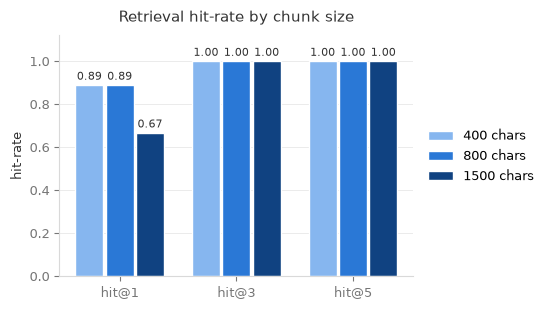

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Ordered sizes -> ordinal single-hue ramp (light -> dark blue)
RAMP = {400: "#86b6ef", 800: "#2a78d6", 1500: "#104281"}
INK, MUTED = "#333333", "#767676"


def style_axes(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#d9d9d9")
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e8e8e8", linewidth=0.6)


ks = (1, 3, 5)
x = np.arange(len(ks))
width = 0.24

fig, ax = plt.subplots(figsize=(5.6, 3.2))
for i, size in enumerate(sizes):
    vals = [chunk_results[size][k] for k in ks]
    bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width,
                  label=f"{size} chars", color=RAMP[size],
                  edgecolor="white", linewidth=1)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, color=INK, padding=2)

ax.set_xticks(x, [f"hit@{k}" for k in ks])
ax.set_ylim(0, 1.12)
ax.set_ylabel("hit-rate", color=INK, fontsize=9)
ax.set_title("Retrieval hit-rate by chunk size", color=INK, fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
style_axes(ax)
plt.tight_layout()
plt.show()

**Conclusion (experiment 1).** 400 and 800 characters tie: hit@1 = 0.89 (8/9),
hit@3 = 1.00. At 1500 characters hit@1 drops to 0.67 (6/9) — exactly the predicted
failure mode: a 1500-char chunk spans several topics, its vector is an average, and
the sharpest match no longer wins the top spot (though it stays within top-3).

**800 is kept as the default**: same accuracy as 400 with 2.3× fewer vectors
(50 vs 114) — a cheaper index, and each retrieved chunk hands the LLM a fuller
piece of context.

*Caveat: with 9 questions one hit = 0.11 of hit-rate, so single-hit differences are
directional, not significant. The 800-vs-1500 gap is two hits.*

## Experiment 2 — embedding model

Production uses `all-MiniLM-L6-v2` (English-only). The candidate alternative is
`paraphrase-multilingual-MiniLM-L12-v2` (50+ languages, incl. Russian). Rule:
**compare fully** — quality *and* size *and* speed, never quality alone.

In [4]:
MODELS = ("all-MiniLM-L6-v2", "paraphrase-multilingual-MiniLM-L12-v2")
model_results = {}

from src.ingest import chunk_text, parse_pdf

docs = [c for page in parse_pdf(PDF) for c in chunk_text(page["text"])]

for name in MODELS:
    # device="cpu": benchmark the DEPLOY target — free cloud containers have no
    # GPU. (On Apple Silicon MPS both models encode equally fast; that number
    # would flatter the bigger model and mislead about production behaviour.)
    model = SentenceTransformer(name, device="cpu")
    params = sum(p.numel() for p in model.parameters())
    col = get_collection(f"exp_model_{name.replace('/', '_')[:40]}")
    ingest_pdf(PDF, collection=col, embedder=model)
    # pure encode speed: min of 5 runs — the least-interference estimate,
    # same convention as timeit (background load only ever slows a run down)
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        model.encode(docs, show_progress_bar=False)
        times.append(time.perf_counter() - t0)
    model_results[name] = {
        "params_m": params / 1e6,
        "size_mb": params * 4 / 1e6,  # fp32 weights
        "chunks_per_s": len(docs) / min(times),
        **hit_rates(questions, model, col),
    }

print(f"{'model':<42}{'params':>8}{'size':>8}{'speed':>12}{'hit@1':>7}{'hit@3':>7}{'hit@5':>7}")
for name, r in model_results.items():
    print(f"{name:<42}{r['params_m']:>7.1f}M{r['size_mb']:>6.0f}MB"
          f"{r['chunks_per_s']:>8.0f} ch/s{r[1]:>7.2f}{r[3]:>7.2f}{r[5]:>7.2f}")

ratio = model_results[MODELS[0]]["chunks_per_s"] / model_results[MODELS[1]]["chunks_per_s"]
print(f"\n-> multilingual L12 encodes {ratio:.1f}x slower than L6 on CPU")

model                                       params    size       speed  hit@1  hit@3  hit@5
all-MiniLM-L6-v2                             22.7M    91MB      92 ch/s   0.89   1.00   1.00
paraphrase-multilingual-MiniLM-L12-v2       117.7M   471MB      87 ch/s   0.89   1.00   1.00

-> multilingual L12 encodes 1.1x slower than L6 on CPU


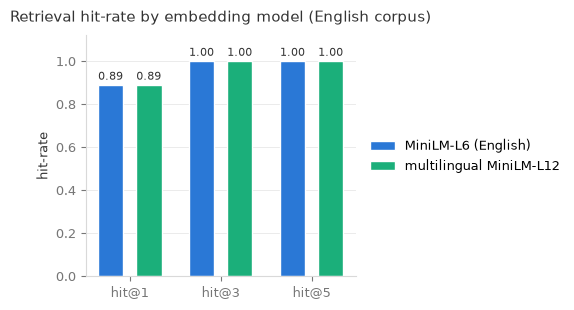

In [5]:
# Two models = categorical identity -> categorical slots (blue, aqua)
COLORS = {MODELS[0]: "#2a78d6", MODELS[1]: "#1baf7a"}
LABELS = {MODELS[0]: "MiniLM-L6 (English)", MODELS[1]: "multilingual MiniLM-L12"}

fig, ax = plt.subplots(figsize=(5.6, 3.2))
w2 = 0.28  # wider gap so the value labels of adjacent bars don't collide
for i, name in enumerate(MODELS):
    vals = [model_results[name][k] for k in ks]
    bars = ax.bar(x + (i - 0.5) * (w2 + 0.14), vals, w2,
                  label=LABELS[name], color=COLORS[name],
                  edgecolor="white", linewidth=1)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, color=INK, padding=2)

ax.set_xticks(x, [f"hit@{k}" for k in ks])
ax.set_ylim(0, 1.12)
ax.set_ylabel("hit-rate", color=INK, fontsize=9)
ax.set_title("Retrieval hit-rate by embedding model (English corpus)",
             color=INK, fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(1.01, 0.5))
style_axes(ax)
plt.tight_layout()
plt.show()

**Conclusion (experiment 2).** On this English corpus the two models retrieve
**identically** — hit@1 = 0.89, hit@3 = 1.00 for both. Batch-encoding throughput on
a multi-core laptop CPU also measured close (exact ratio printed above — min of 5
runs; single-run timings varied up to 2× with machine load, hence the stabilized
benchmark). The decisive measured difference is **memory: 5.2× more parameters**
(117.7M vs 22.7M, ~471 vs ~91 MB) — which matters directly on the deploy target,
a free cloud container with ~2.7 GB RAM and no GPU.

**`all-MiniLM-L6-v2` stays** — equal measured quality at a fraction of the cost,
and the deployment target (a free-tier cloud container) rewards the smaller model.
The interesting nuance: multilingual support cost **no measured accuracy** on
English — so for a mixed-language corpus the L12 model would be the rational
default, paying only in size and speed.

In [6]:
# Clean up experiment collections; the production collection stays untouched.
import chromadb

from src.config import CHROMA_DIR

client = chromadb.PersistentClient(path=CHROMA_DIR)
for c in client.list_collections():
    if c.name.startswith("exp_"):
        client.delete_collection(c.name)
print("remaining collections:", [c.name for c in client.list_collections()])

remaining collections: ['documents']


## Summary — the production configuration is measured, not assumed

| Parameter | Value | Evidence |
|---|---|---|
| Chunk size / overlap | 800 / 100 chars | ties 400 on hit-rate with 2.3× fewer vectors; 1500 loses hit@1 (0.67) |
| Embedding model | all-MiniLM-L6-v2 | equal hit-rate to multilingual-L12 on English at 1/5 the memory footprint |
| Retrieval depth | top-5 | every eval question already resolves within top-3; top-5 adds margin |

Full metrics (hit-rate by question type, per-stage latency, relevance-floor check)
are produced by `python -m eval.run_eval --llm` and reported in the README.